![TD1](/files/Projets/NLP/TP/TD1.jpeg)

# Chargement des données

In [1]:
import shutil, os

src = "/home/merveille/Projets/NLP/TP/kaggle.json"

dst_dir = os.path.expanduser("~/.kaggle")

os.makedirs(dst_dir, exist_ok=True)


shutil.copy(src, dst_dir + "/kaggle.json")

os.chmod(dst_dir + "/kaggle.json", 0o600)

print("Fichier kaggle.json bien configuré !")


Fichier kaggle.json bien configuré !


In [2]:
#télecharger des données
import pandas as pd
import os

csv_path = "/home/merveille/Projets/NLP/TP/IMDB Dataset.csv"
cache_path = "/home/merveille/Projets/NLP/TP/imdb_cache.pkl"

if os.path.exists(cache_path):
    df = pd.read_pickle(cache_path)
    print("Données chargées depuis le cache.")
else:
    df = pd.read_csv(csv_path)
    df.to_pickle(cache_path)
    print("Données téléchargées et sauvegardées localement.")

df.head()


Données chargées depuis le cache.


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 1. Trouver le nombre d'avis positifs et négatifs dans le dataset.

In [3]:
pos=(df['sentiment'] == 'positive').sum()
neg=(df['sentiment'] == 'negative').sum()
print("Nombre d'avis positifs:",pos)
print("Nombre d'avis negatifs",neg)

Nombre d'avis positifs: 25000
Nombre d'avis negatifs 25000


### 2. Trouver la proportion en pourcentage d'avis positifs et négatifs.

In [4]:
total = len(df)
print(total)
p_pos = ( pos / total)*100
p_neg = (neg / total)*100
print(p_pos,"%")
print(p_neg,"%")

50000
50.0 %
50.0 %


### 3. Trouver la longueur de l'avis le plus long

In [5]:
df['longueur'] = df['review'].apply(lambda x: len(x))
avis_plus_long = df['longueur'].max()
print("Longueur de l'avis le plus long :", avis_plus_long)

Longueur de l'avis le plus long : 13704


### 4. Trouver la la critique la plus courte

In [6]:
avis_plus_court = df['longueur'].min()
print("Longueur de la critique la plus courte :", avis_plus_court)

courte_critique = df.loc[df['longueur'] == avis_plus_court, 'review'].iloc[0]
print("Critique la plus courte :")
print("courte_critique")


Longueur de la critique la plus courte : 32
Critique la plus courte :
courte_critique


![TD2](/files/Projets/NLP/TP/TD2.jpeg)

# Calcule de la polarité et de la subjectivité avec TextBlob

In [7]:
#!pip install textblob
#!python -m textblob.download_corpora

from textblob import TextBlob
phr = "One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. Forget pretty pictures painted for mainstream audiences, forget charm, forget romance...OZ doesn't mess around. The first episode I ever saw struck me as so nasty it was surreal, I couldn't say I was ready for it, but as I watched more, I developed a taste for Oz, and got accustomed to the high levels of graphic violence. Not just violence, but injustice (crooked guards who'll be sold out for a nickel, inmates who'll kill on order and get away with it, well mannered, middle class inmates being turned into prison bitches due to their lack of street skills or prison experience) Watching Oz, you may become comfortable with what is uncomfortable viewing....thats if you can get in touch with your darker side."
print(phr)

# Calcul polarité / subjectivité
analyse = TextBlob(phr)
print("\nPolarité :", analyse.sentiment.polarity)
print("Subjectivité :", analyse.sentiment.subjectivity)

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

![TD3](/files/Projets/NLP/TP/TD3.jpeg)

# Nuage de  mots avec WordCloud

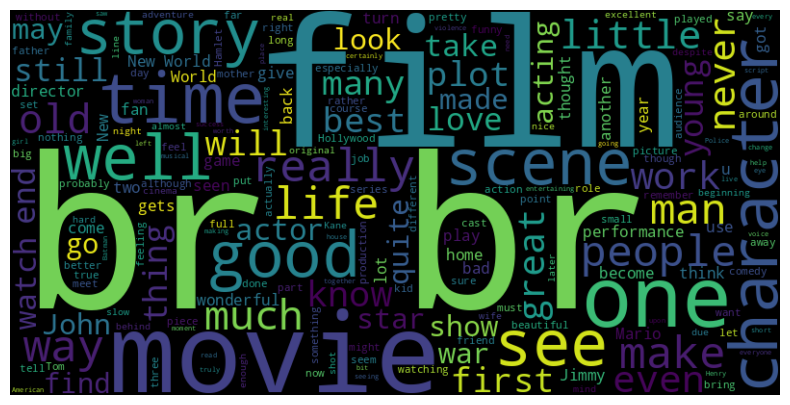

In [8]:
#!pip install wordcloud
#!pip install matplotlib
#1-Nuage de mots
# Choisissons une liste de phrases dans le jeu de données
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt
#choix des phrases
pos_reviews = df[df['sentiment']=='positive']['review'].head(100)
text = " ".join(review for review in pos_reviews)

# Nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Affichons le nuage de mots
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [9]:
my_spopwords = set(STOPWORDS)
my_spopwords.update(["br","movie","film","movies","films","watch"])

<function matplotlib.pyplot.show(close=None, block=None)>

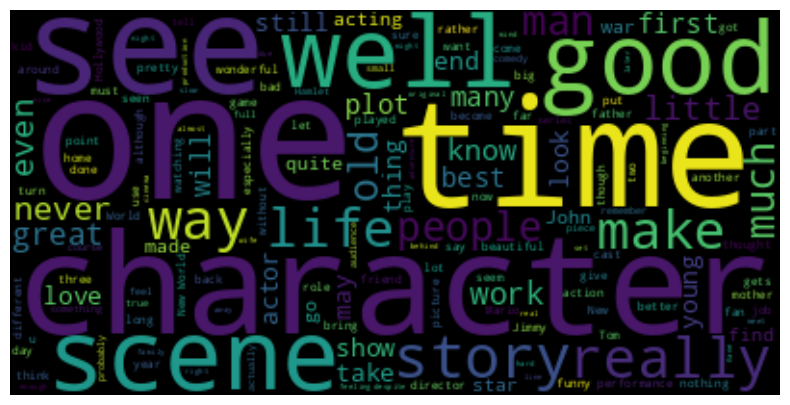

In [10]:
nuage = WordCloud(background_color='black',stopwords=my_spopwords).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(nuage,interpolation='bilinear')
plt.axis('off')
plt.show

les mots les plus fréquents sont: one,time,character,well,see,really,story,best
Cest mots sont coréhant

# TP4: Sac de mots(Bag of Words)

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(max_features=1000)
vect.fit(pos_reviews.to_list())
X = vect.transform(pos_reviews.to_list())
print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 9447 stored elements and shape (100, 1000)>
  Coords	Values
  (0, 7)	1
  (0, 28)	1
  (0, 38)	1
  (0, 52)	1
  (0, 54)	6
  (0, 67)	2
  (0, 70)	1
  (0, 73)	4
  (0, 78)	2
  (0, 88)	2
  (0, 93)	1
  (0, 100)	1
  (0, 120)	6
  (0, 131)	2
  (0, 134)	1
  (0, 137)	1
  (0, 157)	2
  (0, 159)	1
  (0, 167)	1
  (0, 202)	1
  (0, 211)	1
  (0, 224)	1
  (0, 233)	2
  (0, 258)	1
  (0, 263)	1
  :	:
  (99, 810)	1
  (99, 824)	1
  (99, 833)	1
  (99, 846)	2
  (99, 848)	10
  (99, 850)	2
  (99, 858)	4
  (99, 859)	1
  (99, 863)	3
  (99, 876)	5
  (99, 885)	1
  (99, 889)	1
  (99, 892)	1
  (99, 916)	1
  (99, 923)	1
  (99, 945)	2
  (99, 959)	2
  (99, 960)	1
  (99, 966)	2
  (99, 976)	3
  (99, 977)	1
  (99, 978)	1
  (99, 980)	1
  (99, 983)	1
  (99, 987)	1


In [13]:
X.toarray()

array([[0, 0, 0, ..., 3, 0, 1],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(100, 1000))

In [14]:
X_df = pd.DataFrame(X.toarray(), columns=vect.get_feature_names_out())
X_df

,10,15,20,25,30,70s,able,about,above,absolutely,...,written,wrong,year,years,yes,yet,york,you,young,your
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,3,0,1
1,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,1,0,0,0
4,0,1,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,5,0,1
96,0,0,0,0,0,0,1,1,0,0,...,0,0,0,0,1,0,0,1,0,0
97,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
98,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0


# TP4:Vectorization des mots

In [15]:
# Importation du vectoriseur
from sklearn.feature_extraction.text import CountVectorizer
# Construction du vectoriseur
vect = CountVectorizer(ngram_range=(2, 2), max_features=1000, max_df=500)

In [16]:
#les avis du dataframe
reviews = df['review']

In [17]:
vect.fit(reviews.to_list())
X = vect.transform(reviews.to_list())

In [18]:
resultat = pd.DataFrame(X.toarray(), columns=vect.get_feature_names_out())

In [19]:
resultat.head()

,10 br,10 minutes,20 minutes,90 minutes,about an,about as,about her,absolutely no,across as,acting in,...,you in,you must,you need,you that,you the,you were,young man,young woman,your life,your own
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Tokenisation

In [20]:
import nltk
nltk.download('punkt_tab')

text = df['review'][0]

sentences = nltk.sent_tokenize(text)
print(sentences)

["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked.", 'They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO.', 'Trust me, this is not a show for the faint hearted or timid.', 'This show pulls no punches with regards to drugs, sex or violence.', 'Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary.', 'It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda.', "Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the sh

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/merveille/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [21]:
import nltk

text = df['review'][0]

words = nltk.word_tokenize(text)
print(words)

['One', 'of', 'the', 'other', 'reviewers', 'has', 'mentioned', 'that', 'after', 'watching', 'just', '1', 'Oz', 'episode', 'you', "'ll", 'be', 'hooked', '.', 'They', 'are', 'right', ',', 'as', 'this', 'is', 'exactly', 'what', 'happened', 'with', 'me.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'The', 'first', 'thing', 'that', 'struck', 'me', 'about', 'Oz', 'was', 'its', 'brutality', 'and', 'unflinching', 'scenes', 'of', 'violence', ',', 'which', 'set', 'in', 'right', 'from', 'the', 'word', 'GO', '.', 'Trust', 'me', ',', 'this', 'is', 'not', 'a', 'show', 'for', 'the', 'faint', 'hearted', 'or', 'timid', '.', 'This', 'show', 'pulls', 'no', 'punches', 'with', 'regards', 'to', 'drugs', ',', 'sex', 'or', 'violence', '.', 'Its', 'is', 'hardcore', ',', 'in', 'the', 'classic', 'use', 'of', 'the', 'word.', '<', 'br', '/', '>', '<', 'br', '/', '>', 'It', 'is', 'called', 'OZ', 'as', 'that', 'is', 'the', 'nickname', 'given', 'to', 'the', 'Oswald', 'Maximum', 'Security', 'State', 'Penitentary', '.', 

# Tokenavec les colonnes

In [22]:
reviews = df.copy()

In [23]:
reviews.head()

,review,sentiment,longueur
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [24]:
word_tokens = []

def word_tokenise(rev:str):
    return len(nltk.word_tokenize(rev))

In [25]:
reviews['n_tokens'] = reviews['review'].apply(word_tokenise)

In [32]:
reviews.head()

,review,sentiment,longueur,n_tokens
0,One of the other reviewers has mentioned that ...,positive,1761,380
1,A wonderful little production. <br /><br />The...,positive,998,201
2,I thought this was a wonderful way to spend ti...,positive,926,205
3,Basically there's a family where a little boy ...,negative,748,175
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,283


# Detecter une langue

In [33]:
#! pip install langdetect

In [34]:
from langdetect import detect_langs

languages = []

for row in range(len(reviews)):
    languages.append(detect_langs(reviews.iloc[row,1]))
    languages

In [35]:
str(languages[0]).split

<function str.split(sep=None, maxsplit=-1)>

In [36]:
str(languages[0]).split('.')[0]

'[it:0'

In [37]:
str(languages[0]).split('.')[0][1:]

'it:0'

In [38]:
languages.head()

AttributeError: 'list' object has no attribute 'head'

# Stop words

In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = stopwords.words('french')

In [ ]:
stop_words[:10]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

my_stop_words = ENGLISH_STOP_WORDS.union(['film', 'movie', 'cinema', 'theatre'])

In [ ]:
vect = CountVectorizer(stop_words=list(my_stop_words))
vect.fit(reviews['review'].to_list())
X = vect.transform(reviews['review'].to_list())

In [ ]:
import string
print(string.punctuation)

In [ ]:
text = "This is an example :to demonstrate removing stop words."
tokens = word_tokenise(text)
filtered_tokens = [word for word in tokens if word.lower() not in stop_words]

clean_tokens = [word for word in tokens if word not in string.punctuation]
print(clean_tokens)

In [ ]:
#voir si la phrase est composé seulement de lettre
my_string = "arithmetique"
my_string.isalpha()

In [ ]:
#voir si la phrase est composé seulement de digits
my_string.isdigit()

In [ ]:
#voir si la phrase est composé seulement de caracere alphanumerique
my_string.isalnum()

In [ ]:
import re

my_string = "#Wordeday"
x = re.search('#[A-Za-z]', my_string)

In [ ]:
X

# Lowercasing

In [ ]:
text = "Hi POPULATIONS"
print(text.lower())

# Stemming

In [ ]:
from nltk.stem import PorterStemmer

stemer = PorterStemmer()

tokens = ['running', 'grabing', 'lifes', 'mornings', 'cantare', 'vision', 'organization']

stemed = [stemer.stem(t) for t in tokens]
stemed

In [ ]:
from nltk.stem import PorterStemmer

stemer = PorterStemmer()

tokens = ['running', 'attraper', 'vies', 'matinées', 'chanter', 'vision', 'fleurir']

stemed = [stemer.stem(t) for t in tokens]
stemed

# Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmer = WordNetLemmatizer()

tokens = ['coding', 'running', 'lifes', 'mornings', 'cantare', 'vision', 'organization']

lemmed = [lemmer.lemmatize(t) for t in tokens]
lemmed

In [ ]:
from nltk.stem import WordNetLemmatizer

lemmer = WordNetLemmatizer()

tokens = ['vrivre', 'louer', 'courrir', 'matinées', 'chanter', 'vision', 'prier','pensé']

lemmed = [lemmer.lemmatize(t) for t in tokens]
lemmed

In [ ]:
from nltk.stem.snowball import SnowballStemmer

dutchStemmer = SnowballStemmer("french")
dutchStemmer.stem("possibilité")

In [ ]:
from nltk.stem import PorterStemmer

PorterStemmer().stem('Today is a wonderful day!')

* NER
  

In [ ]:
from transformers import pipeline

In [ ]:
ner_pipeline = pipeline(
    task = 'ner',
    model = 'dslim/bert-base-NER',
    grouped_entities = True
)
ner_res = ner_pipeline("My name is Sylvain and I work at Hugging Face in Brooklyn.")
ner_res

# Extractive QA

In [ ]:
qa_pipeline = pipeline(
    task = 'question-answering',
    model = 'distilbert/distilbert-base-cased-distilled-squad'
)
context = """Large Movie Review Dataset. This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. There is additional unlabeled data for use as well."""
question = "What is the name of the dataset?"
qa_res = qa_pipeline(question = question, context = context)

In [ ]:
qa_res

# Abstractive QA

In [ ]:
qa_pipeline = pipeline(
    task = 'text2text-generation',
    model = 'fangyuan/hotpotqa_abstractive'
)
context = """Large Movie Review Dataset. This is a dataset for binary sentiment classification containing substantially more data than previous benchmark datasets. We provide a set of 25,000 highly polar movie reviews for training, and 25,000 for testing. There is additional unlabeled data for use as well."""
question = "What is the name of the dataset?"
input_text = f"question: {question} context: {context}"
qa_res = qa_pipeline(input_text)

In [ ]:
qa_res

# Text Summarization

In [ ]:
summarizer = pipeline(
    task = 'summarization',
    model = 'cnicu/t5-small-booksum'
)

In [ ]:
text = """Reinforcement learning is about learning how to make decisions. Imagine an agent, which could be a software program or a robot, navigating an environment. This environment could be a physical space, a virtual game world, or even a marketplace. The agent performs actions within this environment, and these actions can lead to certain outcomes, some more desirable than others.

The agent's goal is to earn as many rewards as possible over time. To do this, it learns a strategy, which tells it which action to take in a given situation. This strategy is refined through numerous iterations of interaction with the environment.

Consider an AI playing chess. The agent's actions are the moves it makes on the chessboard. The environment is the current state of the game, and the reward is winning. By playing and receiving feedback on its moves, the reinforcement learning agent learns which actions are most likely to lead to victory."""

In [ ]:
res = summarizer(text)
res

# Text translacion

In [ ]:
translator = pipeline(
    task = 'translation',
    model = 'Helsinki-NLP/opus-mt-en-fr'
)

text = """In reinforcement learning, we train agents to accomplish tasks by rewarding desired behaviors. The agent starts with random actions but gradually identifies sequences that maximize its reward score.

The RL workflow involves:
1. Initialization: Agent begins with no knowledge
2. Interaction: Agent acts within an environment
3. Feedback: Environment provides rewards and new states
4. Learning: Agent updates its decision policy
5. Iteration: Process repeats until performance plateaus

This paradigm excels in scenarios requiring long-term planning and sequential decision-making, from game AI to real-world control systems. Modern implementations often combine deep neural networks with traditional RL algorithms, creating powerful 'deep reinforcement learning' systems."""

res = translator(text)